# ENMO_00.jpynb

Repository URL: https://github.com/MarwaSakh/HAH913E-Physical-activity-00-Assignment.git

GROUPE A: Team members: Marwa Sakher, Hafsa Raissi, Jérôme Bosc and their AI friends

## Objective

We have a few minutes of raw data from an accelerometer worn on the non-dominant wrist (Axivity AX3).
The file `0_z.csv` contains 4 columns: `t` (seconds), `x`, `y`, `z` (in g).

The goal is to calculate the **ENMO** (*Euclidean Norm Minus One*), a measure of physical activity intensity,
then **integrate** it over 10-second, 30-second, and 60-second intervals, and plot the result.

## Imports and Parameters

The file begins with a comment line (`# accelerometer data in g`): this line is skipped during reading.
The requested epochs are grouped into a list so they can be looped through.  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# As we `%run` this notebook from another notebook, 
# the path is expected from the other notebook. 
# We need a way to define the path to the file in a way 
# that is independent of the notebook that is running the present notebook.
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

fNameCSV = "data/0_z.csv"
EPOCH_LENGTHS = [10, 30, 60]

## Loading Data

`load_data` reads the CSV file and returns a DataFrame. `get_sampling_rate` calculates the **sampling rate**
based on the median difference between two timestamps (expected: 0.02 s, or 50 Hz).

In [2]:
def load_data(path):
    """Load data (colonnes t, x, y, z), ignore the comment line."""
    return pd.read_csv(path, comment="#")

df = load_data(fNameCSV)
df.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


## Calculating ENMO

Prompt to AI: How calculate ENMO with Python ?  

AI gave us the formula to calculate it, and it suggested removing the negative part.

At rest, an accelerometer measures only gravity: the magnitude of the vector (x, y, z) is approximately **1 g**.
For each data point: $ENMO = \sqrt{x^2 + y^2 + z^2} - 1$ (in g).

**Handling negative values.** In the literature, ENMO is often clipped to 0:
$\max(0,\ \sqrt{x^2+y^2+z^2}-1)$, because a negative value has no physical meaning (it is noise or a slight
calibration error: here, the norm at rest is approximately 0.955 g). Here, we **retain negative values by default**
(`clip_negatives=False`), as in the example provided by the instructor, which results in very small negative values
at rest. The parameter `clip_negatives=True` allows you to switch to the “standard” version in a single line.

In [3]:
def compute_enmo(df, clip_negatives=False):
    """ENMO (in g) for each sample: norm(x, y, z) - 1.
    If clip_negatives=True, negative values are set to 0."""
    enmo = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2) - 1.0
    return enmo.clip(lower=0.0) if clip_negatives else enmo


df["enmo"] = compute_enmo(df)

## Function to compute ENMO integrated  

Prompt to Gemini: Write a Python function to integrate ENMO (in g.min) by epochs of epoch_sec from a DataFrame with t and ENMO.

In [4]:
def aggregate_epochs(df, epoch_s):
    """Integrated ENMO (g·min) per epoch of epoch_s seconds:
    Sum of the ENMO over the epoch multiplied by the epoch duration in minutes."""
    epoch_min = epoch_s / 60
    epoch_id = (df["t"] // epoch_s).astype(int)
    sums = df.groupby(epoch_id)["enmo"].sum()

    return pd.DataFrame({
        "t_start_min": sums.index.to_numpy() * epoch_min,
        "enmo_integrated": sums.to_numpy() * epoch_min,  # g.min
    })


epochs = {L: aggregate_epochs(df, L) for L in EPOCH_LENGTHS}

## Plot the ENMO

Prompt: Write a function to plot 2 subplots for multiple epochs from a dataset with ENMO and time_min. 

`plot_enmo` produces a figure with two plots sharing the same time axis (in minutes):
at the top, the **integrated ENMO per epoch** (bars);
at the bottom, the **raw ENMO** over time, to identify where the peak comes from.

One figure is produced for each epoch length (10 s, 30 s, 60 s).

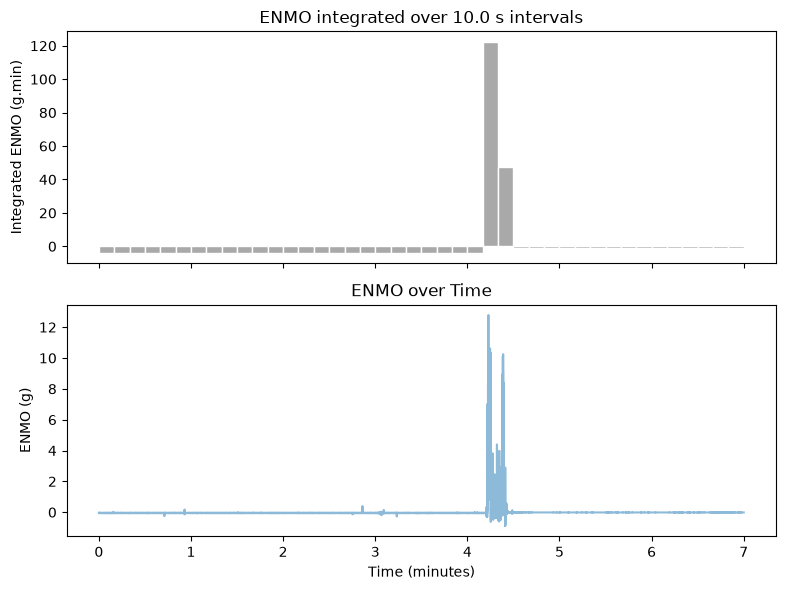

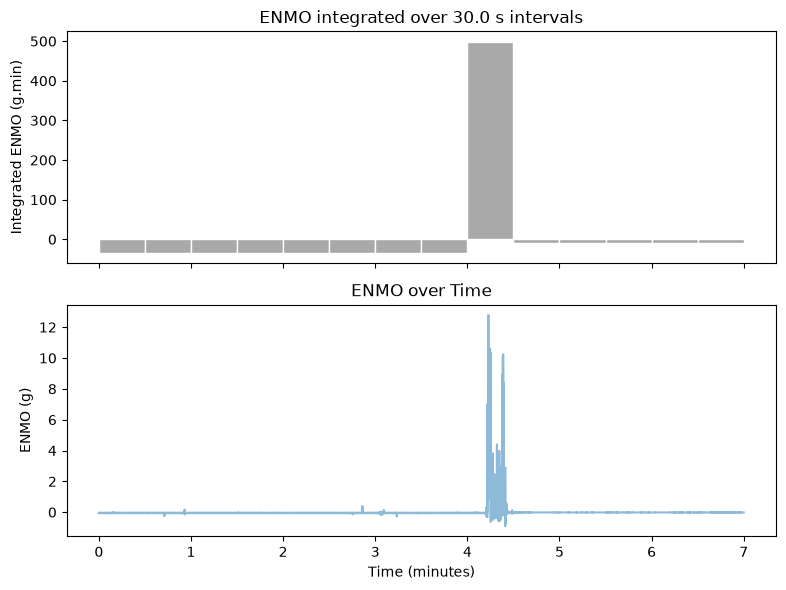

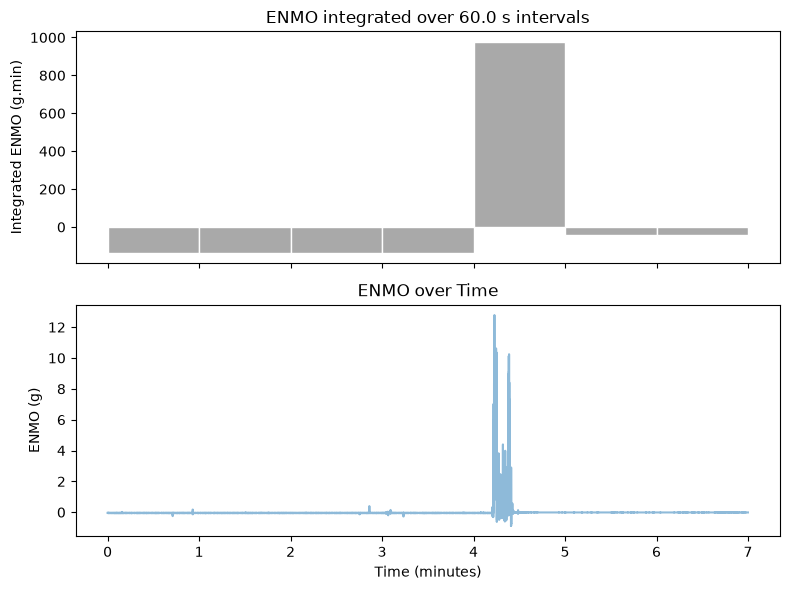

In [5]:
def plot_enmo(df, epoch_df, epoch_s):
    """Figure with 2 graphs: Adjusted ENMO by time period (top) and raw ENMO (bottom)."""
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

    ax1.bar(epoch_df["t_start_min"], epoch_df["enmo_integrated"],
            width=epoch_s / 60, align="edge", color="darkgray", edgecolor="white")
    ax1.set_ylabel("Integrated ENMO (g.min)")
    ax1.set_title(f"ENMO integrated over {epoch_s:.1f} s intervals")

    ax2.plot(df["t"] / 60, df["enmo"], alpha=0.5)
    ax2.set_ylabel("ENMO (g)")
    ax2.set_xlabel("Time (minutes)")
    ax2.set_title("ENMO over Time")

    fig.tight_layout()
    return fig


for L in EPOCH_LENGTHS:
    fig = plot_enmo(df, epochs[L], L)
    #fig.savefig(f"enmo_plot_{L:.1f}s.png", dpi=120)
    plt.show()